Clone the EEGEmotions repository into a folder not tracked by git.

In this case you can just clone it into the project root since the directory of that repository (`EEGEmotions-27`) has been added to .gitignore.
```shell
git clone https://github.com/huytungst/EEGEmotions-27.git
```

All of the emotion labels that we will be using:

| Emotion ID | Emotion         |
|------------|-----------------|
| 1          | admiration      |
| 2          | adoration       |
| 3          | aesthetic       |
| 4          | amusement       |
| 5          | anger           |
| 6          | anxiety         |
| 7          | awes            |
| 8          | awkwardness     |
| 9          | boredom         |
| 10         | calmness        |
| 11         | confusion       |
| 12         | craving         |
| 13         | disgust         |
| 14         | empathic pain   |
| 15         | entrancement    |
| 16         | excitement      |
| 17         | fear            |
| 18         | horror          |
| 19         | interest        |
| 20         | joy             |
| 21         | nostalgia       |
| 22         | relief          |
| 23         | romance         |
| 24         | sadness         |
| 25         | satisfaction    |
| 26         | sexual desire   |
| 27         | surprised       |


Next step is to define the dataset object that PyTorch will use for training.

In [5]:
from pathlib import Path
import os
import numpy as np
import torch
from torch.utils.data import Dataset

emotions = ["admiration", "adoration", "aesthetic", "amusement", "anger", "anxiety", "awes", "awkwardness", "boredom",
            "calmness", "confusion", "craving", "disgust", "empathic pain", "entrancement", "excitation", "fear",
            "horror", "interest", "joy", "nostalgia", "relief", "romance", "sadness", "satisfaction", "sexual desire",
            "surprised"]


class EmotionsEegFftDataset(Dataset):
    """
    Assumes that datadir only contains EEG signals.
    """

    def __init__(self, datadir: Path, sampling_frequency_hz = 256, eeg_signal_samples = 20000, channel_count = 14, frequency_range = (0.5, 50)):
        self.fs = sampling_frequency_hz # sampling frequency of the EEG
        self.eeg_signal_samples = eeg_signal_samples # pad or cut all signals to this size later on

        self.channel_count = channel_count

        min_frequency_hz, max_frequency_hz = frequency_range
        self.frequencies = torch.fft.rfftfreq(self.eeg_signal_samples, d=1 / self.fs)
        self.band_pass_filter = (self.frequencies >= min_frequency_hz) & (self.frequencies <= max_frequency_hz)
        self.frequencies = self.frequencies[self.band_pass_filter] # The frequencies to consider
        self.frequency_count = len(self.frequencies)

        self.datadir = datadir
        self.eeg_data_files = os.listdir(datadir)
        # Extract 0-indexed emotion ID from format `{Participant_ID}_{Emotion_ID}.0.txt`
        self.emotion_labels = [int(filename.split(".", 1)[0].split("_", 1)[1]) - 1 for filename in self.eeg_data_files]

    def __len__(self):
        return len(self.eeg_data_files)

    def __getitem__(self, item):
        filepath = self.datadir / self.eeg_data_files[item]
        eeg_signal = torch.from_numpy(np.loadtxt(filepath))
        mean = eeg_signal.mean(dim=0, keepdim=True)
        std = eeg_signal.std(dim=0, keepdim=True)
        normalized_eeg_signal = (eeg_signal - mean) / std
        eeg_fft_tensor = torch.fft.rfft(normalized_eeg_signal, n = self.eeg_signal_samples, dim = 0)
        eeg_fft_tensor = eeg_fft_tensor[self.band_pass_filter, :]
        emotion_label = self.emotion_labels[item]
        return (
            eeg_fft_tensor,
            torch.zeros(len(emotions), dtype=torch.float).scatter(0, torch.tensor(emotion_label), 1)
        )


We can then initialize the dataset object.

In [6]:
eeg_raw_directory = Path("../EEGEmotions-27/eeg_raw")

dataset = EmotionsEegFftDataset(eeg_raw_directory)

print(f"Found {len(dataset)} EEG signals.")

print(f"FFT length: {len(dataset.frequencies)}")

signal_count_by_emotion = {}
for label in dataset.emotion_labels:
    signal_count_by_emotion[label] = signal_count_by_emotion.get(label, 0) + 1

print(", ".join([f"{emotions[key]}: {value}" for key, value in signal_count_by_emotion.items()]))


Found 2343 EEG signals.
FFT length: 3867
admiration: 88, calmness: 88, confusion: 88, craving: 87, disgust: 86, empathic pain: 86, entrancement: 86, excitation: 86, fear: 86, horror: 86, interest: 87, adoration: 88, joy: 87, nostalgia: 87, relief: 87, romance: 87, sadness: 87, satisfaction: 87, sexual desire: 87, surprised: 82, aesthetic: 88, amusement: 87, anger: 87, anxiety: 87, awes: 87, awkwardness: 87, boredom: 87


Visualize the first 15 samples.

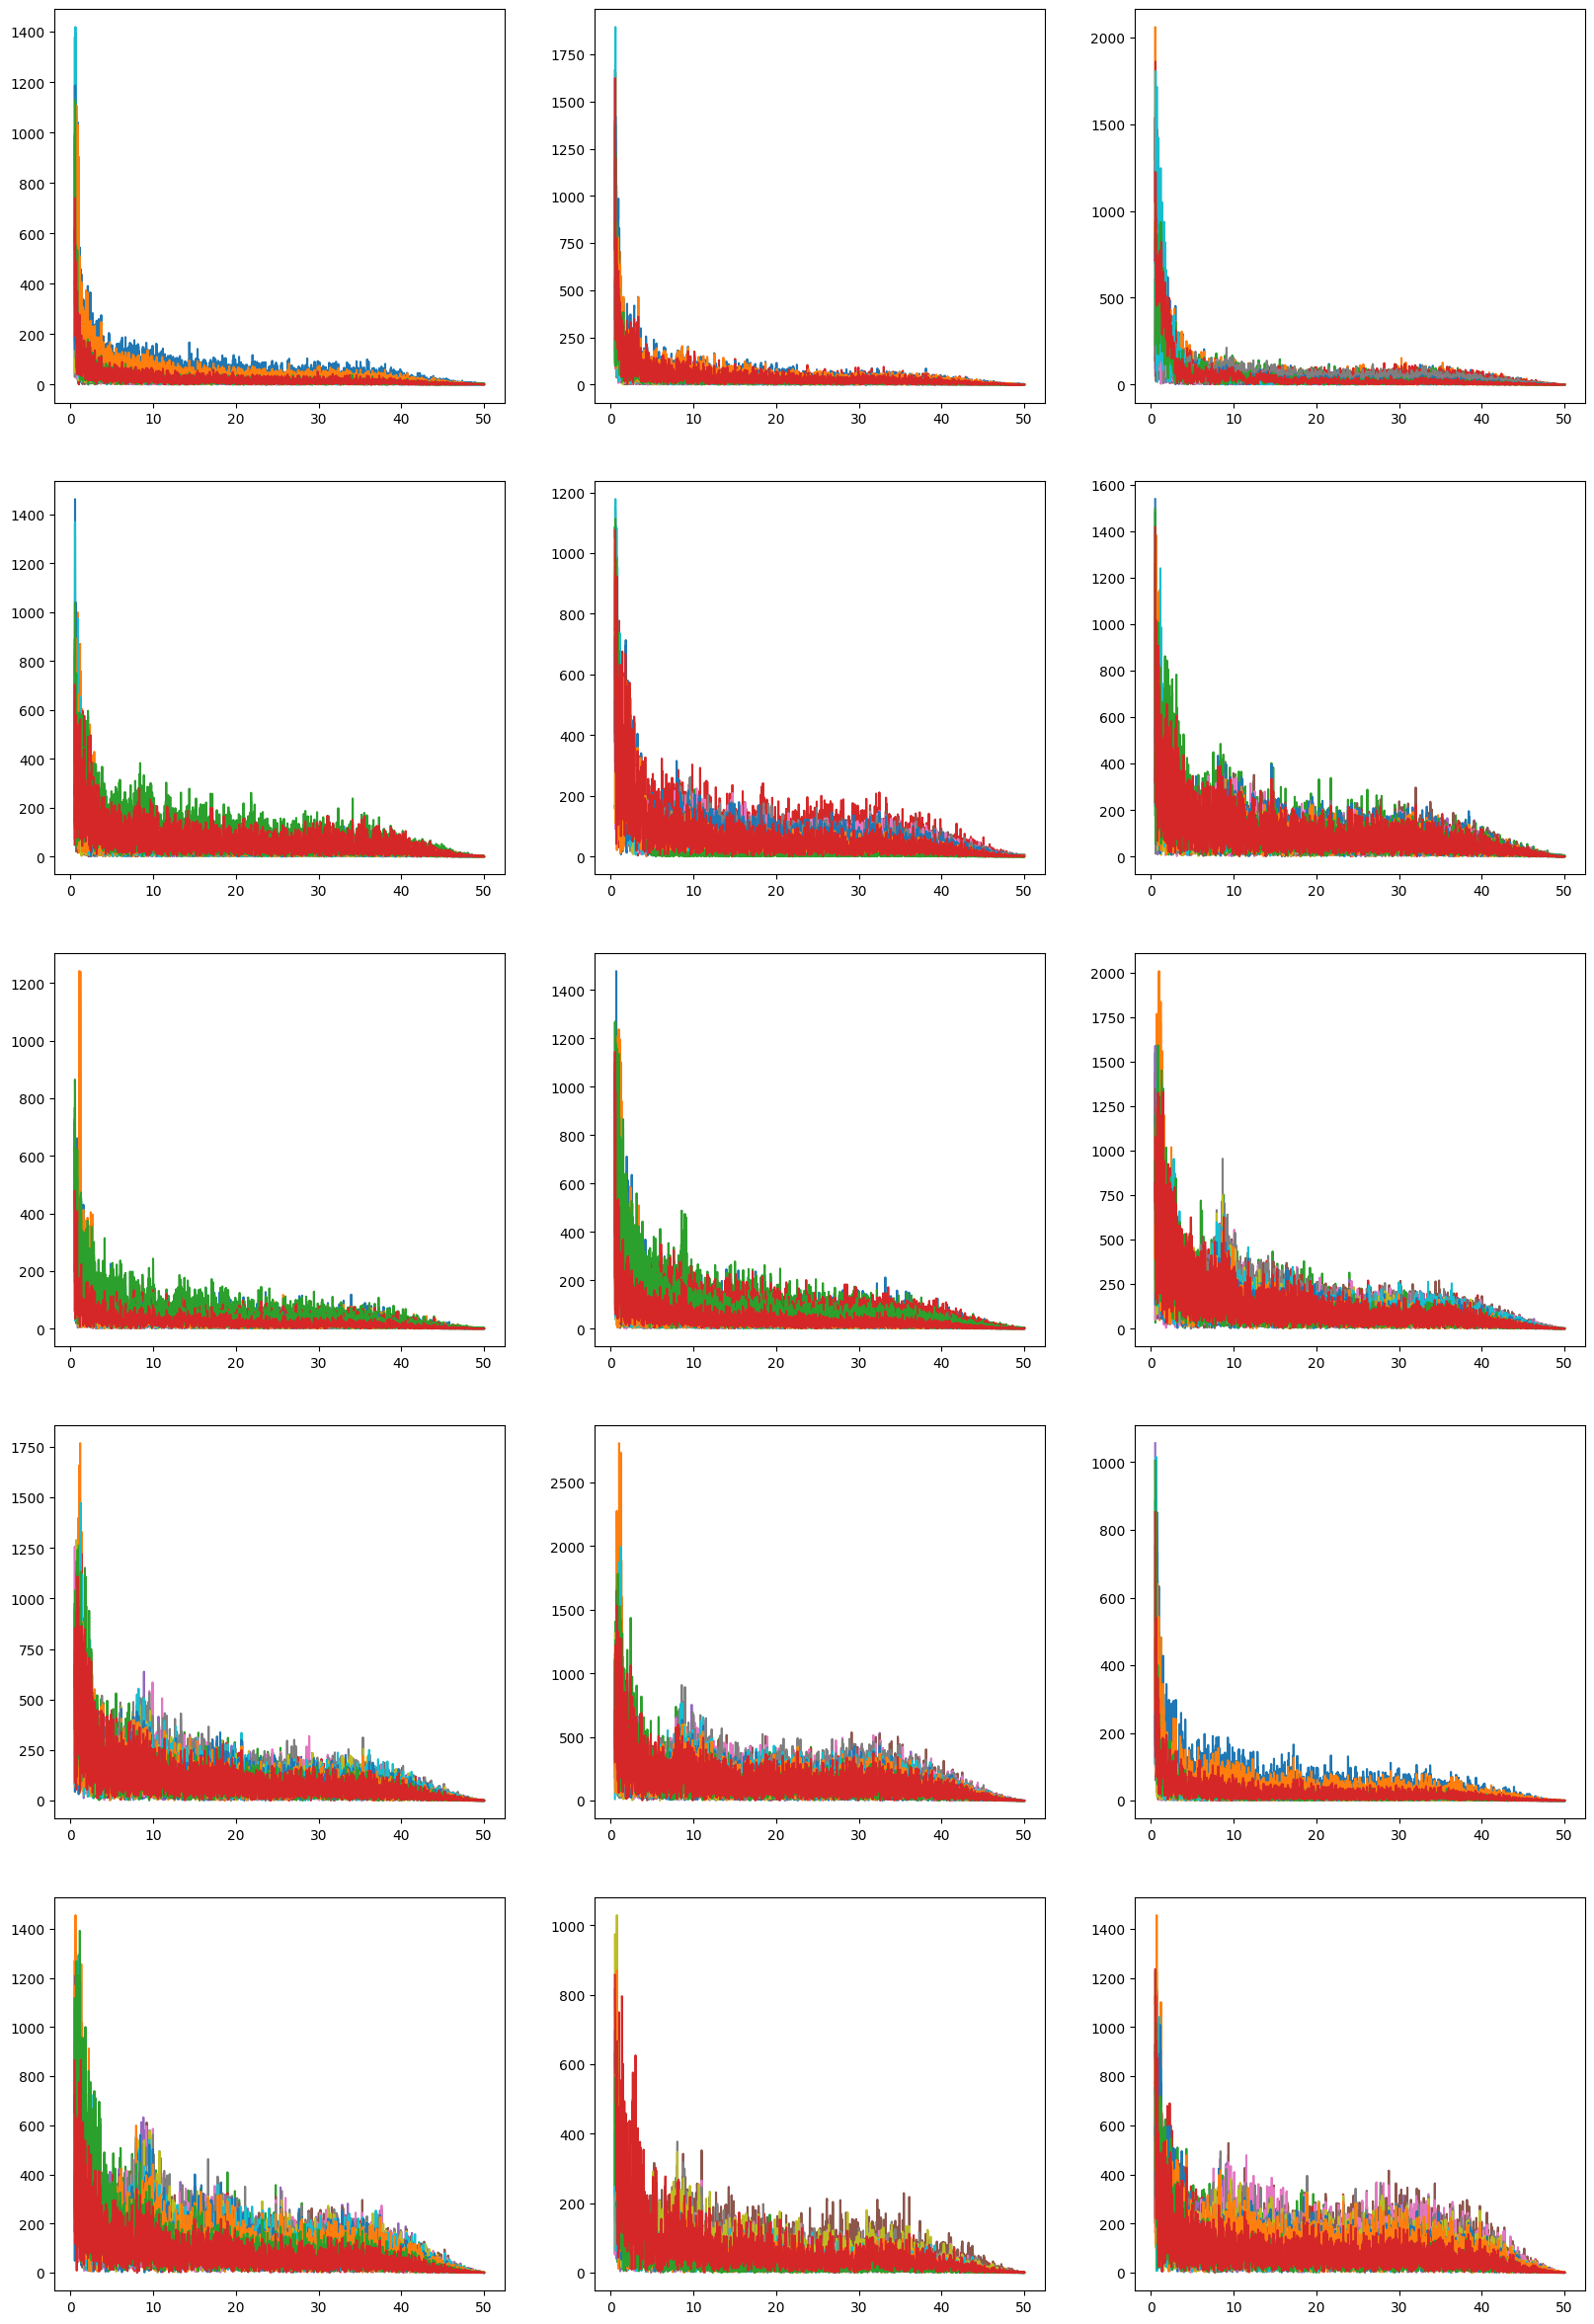

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 30))
for i in range(15):
    fft, label = dataset[i]

    abs_fft = torch.abs(fft)
    plt.subplot(5, 3, i+1)
    plt.plot(dataset.frequencies, abs_fft)


Split the dataset into test and train


In [9]:
from torch.utils.data import random_split

seed = 69

train_dataset, validation_dataset, test_dataset = random_split(dataset, [.8, .1, .1], torch.manual_seed(seed))

Define the neural network.

In [10]:
from torch import nn

class EegFftNetwork(nn.Module):
    def __init__(self, frequency_count, channel_count):
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(frequency_count * channel_count, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 27),
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits

Create an instance of the neural network.

In [11]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
model = EegFftNetwork(dataset.frequency_count, dataset.channel_count).to(device)
print(model)

EegFftNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=54138, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=27, bias=True)
  )
)
